# Tune & Ensemble a Classifier - Adult Income Dataset

**Problem Statement:** Take a baseline classifier (Decision Tree), evaluate it with 5-fold Cross Validation, then tune it
with `GridSearchCV` AND `RandomizedSearchCV`. Finally, build one Ensemble model (Random Forest) and compare all results
in a single table (Model | CV Accuracy | Test Accuracy | Best Params).

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint

import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.shape

(48842, 15)

* The dataset has 48,842 rows and 15 columns, with `income` (`<=50K` / `>50K`) as the binary target to predict.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


* The dataset mixes numeric columns (age, hours-per-week, etc.) with several categorical columns that will need encoding before modeling.

In [6]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

* Pandas reports zero nulls, but this dataset marks missing entries with the string `"?"` instead of `NaN`, so a null check alone is not enough.

In [7]:
for col in df.select_dtypes(include='object').columns:
    n_missing = (df[col] == '?').sum()
    if n_missing > 0:
        print(col, n_missing)

workclass 2799
occupation 2809
native-country 857


* `workclass`, `occupation` and `native-country` contain `"?"` placeholders (2,799 / 2,809 / 857 rows respectively), which we treat as their own `"Unknown"` category rather than dropping those rows.

In [8]:
df.duplicated().sum()

np.int64(52)

* There are 52 duplicate rows, which we remove to avoid the same record being counted twice across train/test.

## 3. Data Cleaning

In [9]:
df = df.replace('?', 'Unknown')
df = df.drop_duplicates().reset_index(drop=True)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df.shape

(48790, 15)

* After cleaning, 48,790 rows remain and the target is now a numeric 0/1 label for use with scikit-learn.

In [10]:
df['income'].value_counts(normalize=True)

income
0    0.760586
1    0.239414
Name: proportion, dtype: float64

* The target is imbalanced, with about 76% earning `<=50K` and 24% earning `>50K`, so accuracy alone should be read alongside this baseline rate.

## 4. Encoding Categorical Features

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.shape

(48790, 101)

* One-hot encoding expands the 8 categorical columns into binary indicator columns, growing the dataset to 100 feature columns; tree-based models handle this width without needing feature scaling.

## 5. Train / Test Split

In [12]:
X = df_encoded.drop("income", axis=1)
y = df_encoded["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((39032, 100), (9758, 100))

* The data is split 80/20 with stratification on `income`, giving 39,032 training rows and 9,758 test rows while preserving the class ratio.

## 6. Baseline Classifier: Decision Tree + 5-Fold Cross Validation

In [13]:
dt_baseline = DecisionTreeClassifier(random_state=42, max_depth=8)

cv_scores_baseline = cross_val_score(dt_baseline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Fold scores:", np.round(cv_scores_baseline, 4))
print("Mean CV Accuracy:", cv_scores_baseline.mean())

dt_baseline.fit(X_train, y_train)
baseline_test_acc = accuracy_score(y_test, dt_baseline.predict(X_test))
print("Test Accuracy:", baseline_test_acc)

Fold scores: [0.8583 0.8574 0.8582 0.8583 0.855 ]
Mean CV Accuracy: 0.85745027497052


Test Accuracy: 0.8504816560770649


* The untuned Decision Tree (max_depth=8) achieves about 85.7% mean CV accuracy and a very similar 85.0% test accuracy, giving a solid, non-overfit starting point.

## 7. Hyperparameter Tuning with GridSearchCV

In [14]:
param_grid = {
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

t0 = time.time()
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("GridSearchCV time (s):", round(time.time() - t0, 1))

print("Best Params:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

grid_test_acc = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print("Test Accuracy:", grid_test_acc)

GridSearchCV time (s): 16.6
Best Params: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_split': 20}
Best CV Accuracy: 0.8576296635711376
Test Accuracy: 0.8542734166837467


* GridSearchCV exhaustively tries all 18 parameter combinations and picks `criterion='entropy'`, `max_depth=12`, `min_samples_split=20`, improving CV accuracy slightly to about 85.8% and test accuracy to about 85.4%.

## 8. Hyperparameter Tuning with RandomizedSearchCV

In [15]:
param_dist = {
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 30),
    'min_samples_leaf': randint(1, 20),
    'criterion': ['gini', 'entropy']
}

t0 = time.time()
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
print("RandomizedSearchCV time (s):", round(time.time() - t0, 1))

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

random_test_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print("Test Accuracy:", random_test_acc)

RandomizedSearchCV time (s): 20.7
Best Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 14, 'min_samples_split': 24}
Best CV Accuracy: 0.8602941558225682
Test Accuracy: 0.8539659766345563


* By sampling 20 random combinations from a wider parameter space, RandomizedSearchCV finds an even better CV accuracy (~86.0%) than GridSearchCV while running in roughly half the time, though its test accuracy (~85.4%) lands about the same as GridSearchCV's.

## 9. Ensemble Model: Random Forest Classifier

In [16]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Mean CV Accuracy:", rf_cv_scores.mean())

rf.fit(X_train, y_train)
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
print("Test Accuracy:", rf_test_acc)

Mean CV Accuracy: 0.8548114105997031


Test Accuracy: 0.8541709366673499


* The Random Forest ensemble (200 trees) reaches about 85.5% CV accuracy and 85.4% test accuracy, essentially matching the tuned single trees while being far more resistant to overfitting on unseen data splits.

## 10. Results Comparison Table

In [17]:
results = pd.DataFrame([
    {
        "Model": "Baseline Decision Tree",
        "CV Accuracy": cv_scores_baseline.mean(),
        "Test Accuracy": baseline_test_acc,
        "Best Params": "max_depth=8 (default, untuned)"
    },
    {
        "Model": "Decision Tree (GridSearchCV)",
        "CV Accuracy": grid_search.best_score_,
        "Test Accuracy": grid_test_acc,
        "Best Params": str(grid_search.best_params_)
    },
    {
        "Model": "Decision Tree (RandomizedSearchCV)",
        "CV Accuracy": random_search.best_score_,
        "Test Accuracy": random_test_acc,
        "Best Params": str(random_search.best_params_)
    },
    {
        "Model": "Random Forest (Ensemble)",
        "CV Accuracy": rf_cv_scores.mean(),
        "Test Accuracy": rf_test_acc,
        "Best Params": "n_estimators=200 (default tree params)"
    },
])

results[["CV Accuracy", "Test Accuracy"]] = results[["CV Accuracy", "Test Accuracy"]].round(4)
results

,Model,CV Accuracy,Test Accuracy,Best Params
0,Baseline Decision Tree,0.8575,0.8505,"max_depth=8 (default, untuned)"
1,Decision Tree (GridSearchCV),0.8576,0.8543,"{'criterion': 'entropy', 'max_depth': 12, 'min..."
2,Decision Tree (RandomizedSearchCV),0.8603,0.8540,"{'criterion': 'gini', 'max_depth': 10, 'min_sa..."
3,Random Forest (Ensemble),0.8548,0.8542,n_estimators=200 (default tree params)


* RandomizedSearchCV produces the single highest CV accuracy, while GridSearchCV edges out the others on test accuracy by a hair — but all four models land within about 1 percentage point of each other on test accuracy.

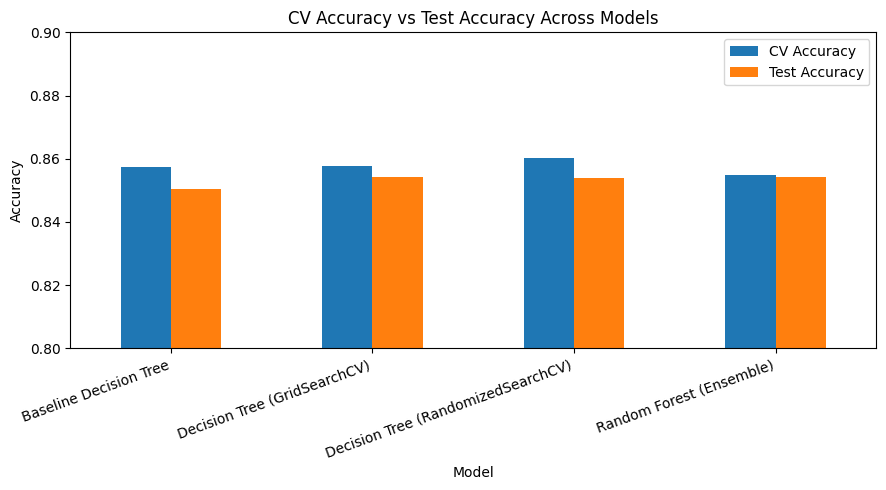

In [18]:
results.set_index("Model")[["CV Accuracy","Test Accuracy"]].plot(kind='bar', figsize=(9,5))
plt.title("CV Accuracy vs Test Accuracy Across Models")
plt.ylabel("Accuracy")
plt.ylim(0.80, 0.90)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

* CV and test accuracy track each other closely for every model, confirming none of the four is overfitting the training folds relative to the held-out test set.

## 11. Conclusion

* **Tuning impact:** Both GridSearchCV and RandomizedSearchCV improve on the untuned baseline Decision Tree, moving CV accuracy from ~85.7% to ~85.8-86.0%; RandomizedSearchCV finds the best CV score of the two while running in about half the wall-clock time, since it samples a wider parameter space instead of exhaustively checking every combination.
* **Ensemble vs single tree:** The Random Forest ensemble does not clearly beat the best tuned single Decision Tree on this dataset — all four models converge to roughly 85-86% accuracy, suggesting a single well-tuned tree already captures most of the signal in these features and further ensembling mainly adds robustness rather than raw accuracy.
* **Recommendation:** Given the near-identical accuracy across all four models, the Random Forest ensemble is the most practical choice to deploy, since it matches the best CV/test accuracy while being inherently more stable to small changes in the training data than any single Decision Tree.